# **Formation CLassifier using Well Logs**
### Developed by Alfonso Vecino - 2026

In [89]:
# Libraries for data science
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd

# Operating System: make the code compatible with different platforms: Windows, Mac and Linux
import os

#Suppresing the warnings
import warnings
warnings.filterwarnings('ignore')


## **Variable Description**

**Well Identification and Location**
* WELL: Unique well identifier.
* DEPTH_MD: Measured depth (MD) in meters (vertical distance down the wellbore).
* X_LOC, Y_LOC: Easting and Northing coordinates (well's horizontal position, likely UTM).
* Z_LOC: Depth in a vertical coordinate system (elevation relative to sea level, different from DEPTH_MD).

**Geological Information (Ground Truth)**
* GROUP: Broader geological grouping of formations.
* FORMATION: Specific geological formation at a given depth (finer subdivision than GROUP).
* FORCE_2020_LITHOFACIES_LITHOLOGY: Target variable: lithology (rock type) at each depth (categorical, with codes for different lithologies).
* FORCE_2020_LITHOFACIES_CONFIDENCE: Confidence in the assigned lithology label (important for evaluating model performance).

**Well Log Measurements (Features)**
* CALI: Caliper log (borehole diameter).
* RSHA: Shallow resistivity log.
* RMED: Medium resistivity log.
* RDEP: Deep resistivity log.
* RHOB: Bulk density log.
* GR: Gamma-ray log.
* SGR: Spectral gamma ray log.
* NPHI: Neutron porosity log.
* PEF: Photoelectric factor log.
* DTC: Sonic/acoustic log (sound wave travel time).
* SP: Spontaneous potential log [mV].
* BS: Bit size (diameter of the drill bit).
* ROP: Rate of penetration (drilling speed).
* DTS: Shear wave velocity log.
* DCAL: Difference between caliper and bit size.
* DRHO: Density correction.
* MUDWEIGHT: Density of the drilling mud.
* RMIC: Micro-resistivity log.
* ROPA: Processed/interpreted resistivity measurement.
* RXO: Resistivity of the flushed zone.

**Formation CLassification**
| Code | Lithology |
| :--- | :--- |
| 30000 | Sandstone |
| 65030 | Sandstone/Shale |
| 65000 | Shale |
| 80000 | Marl |
| 74000 | Dolomite |
| 70000 | Limestone |
| 70032 | Chalk |
| 88000 | Halite |
| 86000 | Anhydrite |
| 99000 | Tuff |
| 90000 | Coal |
| 93000 | Basement |

**Source**: https://www.kaggle.com/datasets/faresazzam/well-logs-dataset-for-machine-learning

## **Exploratory Data Analysis**

In [90]:
df = pd.read_csv('15_9-23.csv')
well1 = df.copy()
well1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11063 entries, 0 to 11062
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   WELL                               11063 non-null  object 
 1   DEPTH_MD                           11063 non-null  float64
 2   X_LOC                              11063 non-null  float64
 3   Y_LOC                              11063 non-null  float64
 4   Z_LOC                              11063 non-null  float64
 5   GROUP                              11063 non-null  object 
 6   FORMATION                          11063 non-null  object 
 7   CALI                               11063 non-null  float64
 8   RSHA                               0 non-null      float64
 9   RMED                               11009 non-null  float64
 10  RDEP                               11063 non-null  float64
 11  RHOB                               11009 non-null  flo

In [91]:
# Droping the columns without information
well1.drop(columns=['RSHA', 'SGR', 'SP', 'MUDWEIGHT', 'RMIC', 'RXO'], inplace=True)
well1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11063 entries, 0 to 11062
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   WELL                               11063 non-null  object 
 1   DEPTH_MD                           11063 non-null  float64
 2   X_LOC                              11063 non-null  float64
 3   Y_LOC                              11063 non-null  float64
 4   Z_LOC                              11063 non-null  float64
 5   GROUP                              11063 non-null  object 
 6   FORMATION                          11063 non-null  object 
 7   CALI                               11063 non-null  float64
 8   RMED                               11009 non-null  float64
 9   RDEP                               11063 non-null  float64
 10  RHOB                               11009 non-null  float64
 11  GR                                 11063 non-null  flo

In [92]:
well1['DEPTH_MD'].describe()

count    11063.000000
mean      2367.135122
std        490.393818
min       1518.280000
25%       1938.636000
50%       2371.000000
75%       2791.356000
max       3212.624000
Name: DEPTH_MD, dtype: float64

### Categorical Variables Summary

In [93]:
# First any categorical variable is extracted in a list
cat_var = well1.select_dtypes(include=['object']).columns

# If there are no categorical variables, it stops and exit
if len(cat_var) == 0:
    print("No categorical variables found.")
    sys.exit()
    
# Iterate each categorical variable
for var in cat_var:
    
    print(f"\n--- Analysis for: {var} ---")
    
    # Calculate Counts and Percentages
    counts = well1[var].value_counts()
    percent = well1[var].value_counts(normalize=True) * 100
    
    # Combine into a readable DataFrame
    summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percent.round(2)
    })
    
    print(summary)



--- Analysis for: WELL ---
         Count  Percentage (%)
WELL                          
15/9-23  11063           100.0

--- Analysis for: GROUP ---
                  Count  Percentage (%)
GROUP                                  
HORDALAND GP.      5216           47.15
SHETLAND GP.       2237           20.22
ROGALAND GP.       1480           13.38
VIKING GP.          980            8.86
VESTLAND GP.        827            7.48
CROMER KNOLL GP.    323            2.92

--- Analysis for: FORMATION ---
               Count  Percentage (%)
FORMATION                           
Skade Fm.       3763           34.01
Frigg Fm.       1453           13.13
Tor Fm.         1177           10.64
Lista Fm.        704            6.36
Draupne Fm.      658            5.95
Sleipner Fm.     540            4.88
Hod Fm.          533            4.82
Sele Fm.         474            4.28
Heather Fm.      322            2.91
Blodoeks Fm.     305            2.76
Skagerrak Fm.    287            2.59
Hidra Fm.       

### Checking Outliers

In [94]:
# All numerical variables stored for the analysis into a list
num_var = well1.select_dtypes(exclude=['object']).columns
# Dictionary to store the results
outliers_dict = {}

# Iterate each variable to calculate the outliers using the interquartile (IQR) range method:
for var in num_var:
    
    # Calculate the quartiles
    q1 = well1[var].quantile(0.25)
    q3 = well1[var].quantile(0.75)
    IQR = q3 - q1
    
    # Define bounds (standard multiplier is 1.5)
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    
    # Identify outliers using indexing
    outliers = well1[(well1[var] < lower_bound) | (well1[var] > upper_bound)][var]
    
    # Store them into a dictionary
    outliers_dict[var] = outliers.tolist()

# Print the results
for var, values in outliers_dict.items():
    print(f"--- Outliers in {var} ---")
    if len(values) > 0:
        print(f"Total outliers: {len(values)}")
        print(f"min outlier: {min(values)}")
        print(f"max outlier: {max(values)}")
        print(f"variable mean: {well1[var].mean()}")
        values.sort()
        print(f"Values: {values}")
    else:
        print("No outliers detected.")
    print("\n")


--- Outliers in DEPTH_MD ---
No outliers detected.


--- Outliers in X_LOC ---
No outliers detected.


--- Outliers in Y_LOC ---
No outliers detected.


--- Outliers in Z_LOC ---
No outliers detected.


--- Outliers in CALI ---
Total outliers: 1665
min outlier: 8.2635173798
max outlier: 19.163352966
variable mean: 12.043441877888085
Values: [8.2635173798, 8.2661333084, 8.2763404846, 8.2862100601, 8.3199052811, 8.3385000229, 8.3478326797, 8.3762702942, 8.3769302368, 8.3796348572, 8.3856191635, 8.3952980042, 8.395608902, 8.3962068558, 8.3987550735, 8.4058866501, 8.4078769684, 8.41203022, 8.4128170013, 8.4156084061, 8.4220600128, 8.4233455658, 8.4248323441, 8.4252567291, 8.4255437851, 8.4260482788, 8.4275913239, 8.4276504517, 8.4287405014, 8.4316244125, 8.4342727661, 8.4346761703, 8.4366779327, 8.4374170303, 8.4383497238, 8.4401044846, 8.4414396286, 8.4420404434, 8.4452466965, 8.4465999603, 8.4472646713, 8.4474115372, 8.4490194321, 8.4502296448, 8.4503688812, 8.4518613815, 8.4534606934, 8

**Observation:** Considering that detected outliers had no significant impact on variables, I decided to left them as they are.


### Missing Values

In [95]:
well1.isnull().sum()

WELL                                   0
DEPTH_MD                               0
X_LOC                                  0
Y_LOC                                  0
Z_LOC                                  0
GROUP                                  0
FORMATION                              0
CALI                                   0
RMED                                  54
RDEP                                   0
RHOB                                  54
GR                                     0
NPHI                                  26
PEF                                  226
DTC                                  122
BS                                     0
ROP                                   36
DTS                                  639
DCAL                                   0
DRHO                                   0
ROPA                                  39
FORCE_2020_LITHOFACIES_LITHOLOGY       0
FORCE_2020_LITHOFACIES_CONFIDENCE      4
dtype: int64

**Observation:** To handle the missing values for this well:
* **RMED**: Impute the mean of the formation detected.
* **RHOB**: Impute the mean of the formation detected.
* **NPHI**: Impute the mean of the formation detected.
* **PEF**: Impute the mean of the formation detected.
* **DTC**: Impute the mean of the formation detected.
* **ROP**: Impute mean of variable.
* **DTS**: Impute mean of variable.
* **ROPA**: Impute the mean of the formation detected.
* **FORCE_2020_LITHOFACIES_CONFIDENCE**: Drop missing values.

In [96]:
# Handling missing values
well1['RMED'] = well1['RMED'].fillna(well1.groupby('FORMATION')['RMED'].transform('mean'))
well1['RHOB'] = well1['RHOB'].fillna(well1.groupby('FORMATION')['RHOB'].transform('mean'))
well1['NPHI'] = well1['NPHI'].fillna(well1.groupby('FORMATION')['NPHI'].transform('mean'))
well1['PEF'] = well1['PEF'].fillna(well1.groupby('FORMATION')['PEF'].transform('mean'))
well1['DTC'] = well1['DTC'].fillna(well1.groupby('FORMATION')['DTC'].transform('mean'))
well1['ROP'] = well1['ROP'].fillna(well1['ROP'].mean())
well1['DTS'] = well1['DTS'].fillna(well1['DTS'].mean())
well1['ROPA'] = well1['ROPA'].fillna(well1.groupby('FORMATION')['ROPA'].transform('mean'))
well1 = well1.dropna(subset=['FORCE_2020_LITHOFACIES_CONFIDENCE'])
# Reset index
well1.reset_index(drop=True, inplace=True)
well1.isnull().sum().sum()

np.int64(0)

### Plotting available data

In [97]:
well1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11059 entries, 0 to 11058
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   WELL                               11059 non-null  object 
 1   DEPTH_MD                           11059 non-null  float64
 2   X_LOC                              11059 non-null  float64
 3   Y_LOC                              11059 non-null  float64
 4   Z_LOC                              11059 non-null  float64
 5   GROUP                              11059 non-null  object 
 6   FORMATION                          11059 non-null  object 
 7   CALI                               11059 non-null  float64
 8   RMED                               11059 non-null  float64
 9   RDEP                               11059 non-null  float64
 10  RHOB                               11059 non-null  float64
 11  GR                                 11059 non-null  flo

In [100]:
# Formation depths
formations = {
    "Skade Fm.": 2091.928,
    "Frigg Fm.": 2322.968,
    "Balder Fm.": 2344.856,
    "Sele Fm.": 2416.904,
    "Lista Fm.": 2523.912,
    "Ty Fm.": 2547.928,
    "Ekofisk Fm.": 2550.968,
    "Tor Fm.": 2729.872,
    "Hod Fm.": 2810.888,
    "Blodoeks": 2857.856,
    "Hidra Fm.": 2888.864,
    "Roedby Fm.": 2897.984,
    "Sola Fm.": 2916.984,
    "Tuxen Fm.": 2928.992,
    "Aasgard Fm.": 2937.96,
    "Draupne Fm.": 3037.976,
    "Heather Fm.": 3086.92,
    "Sleipner Fm.": 3169.0,
    "Skagerrak": 3212.624
}

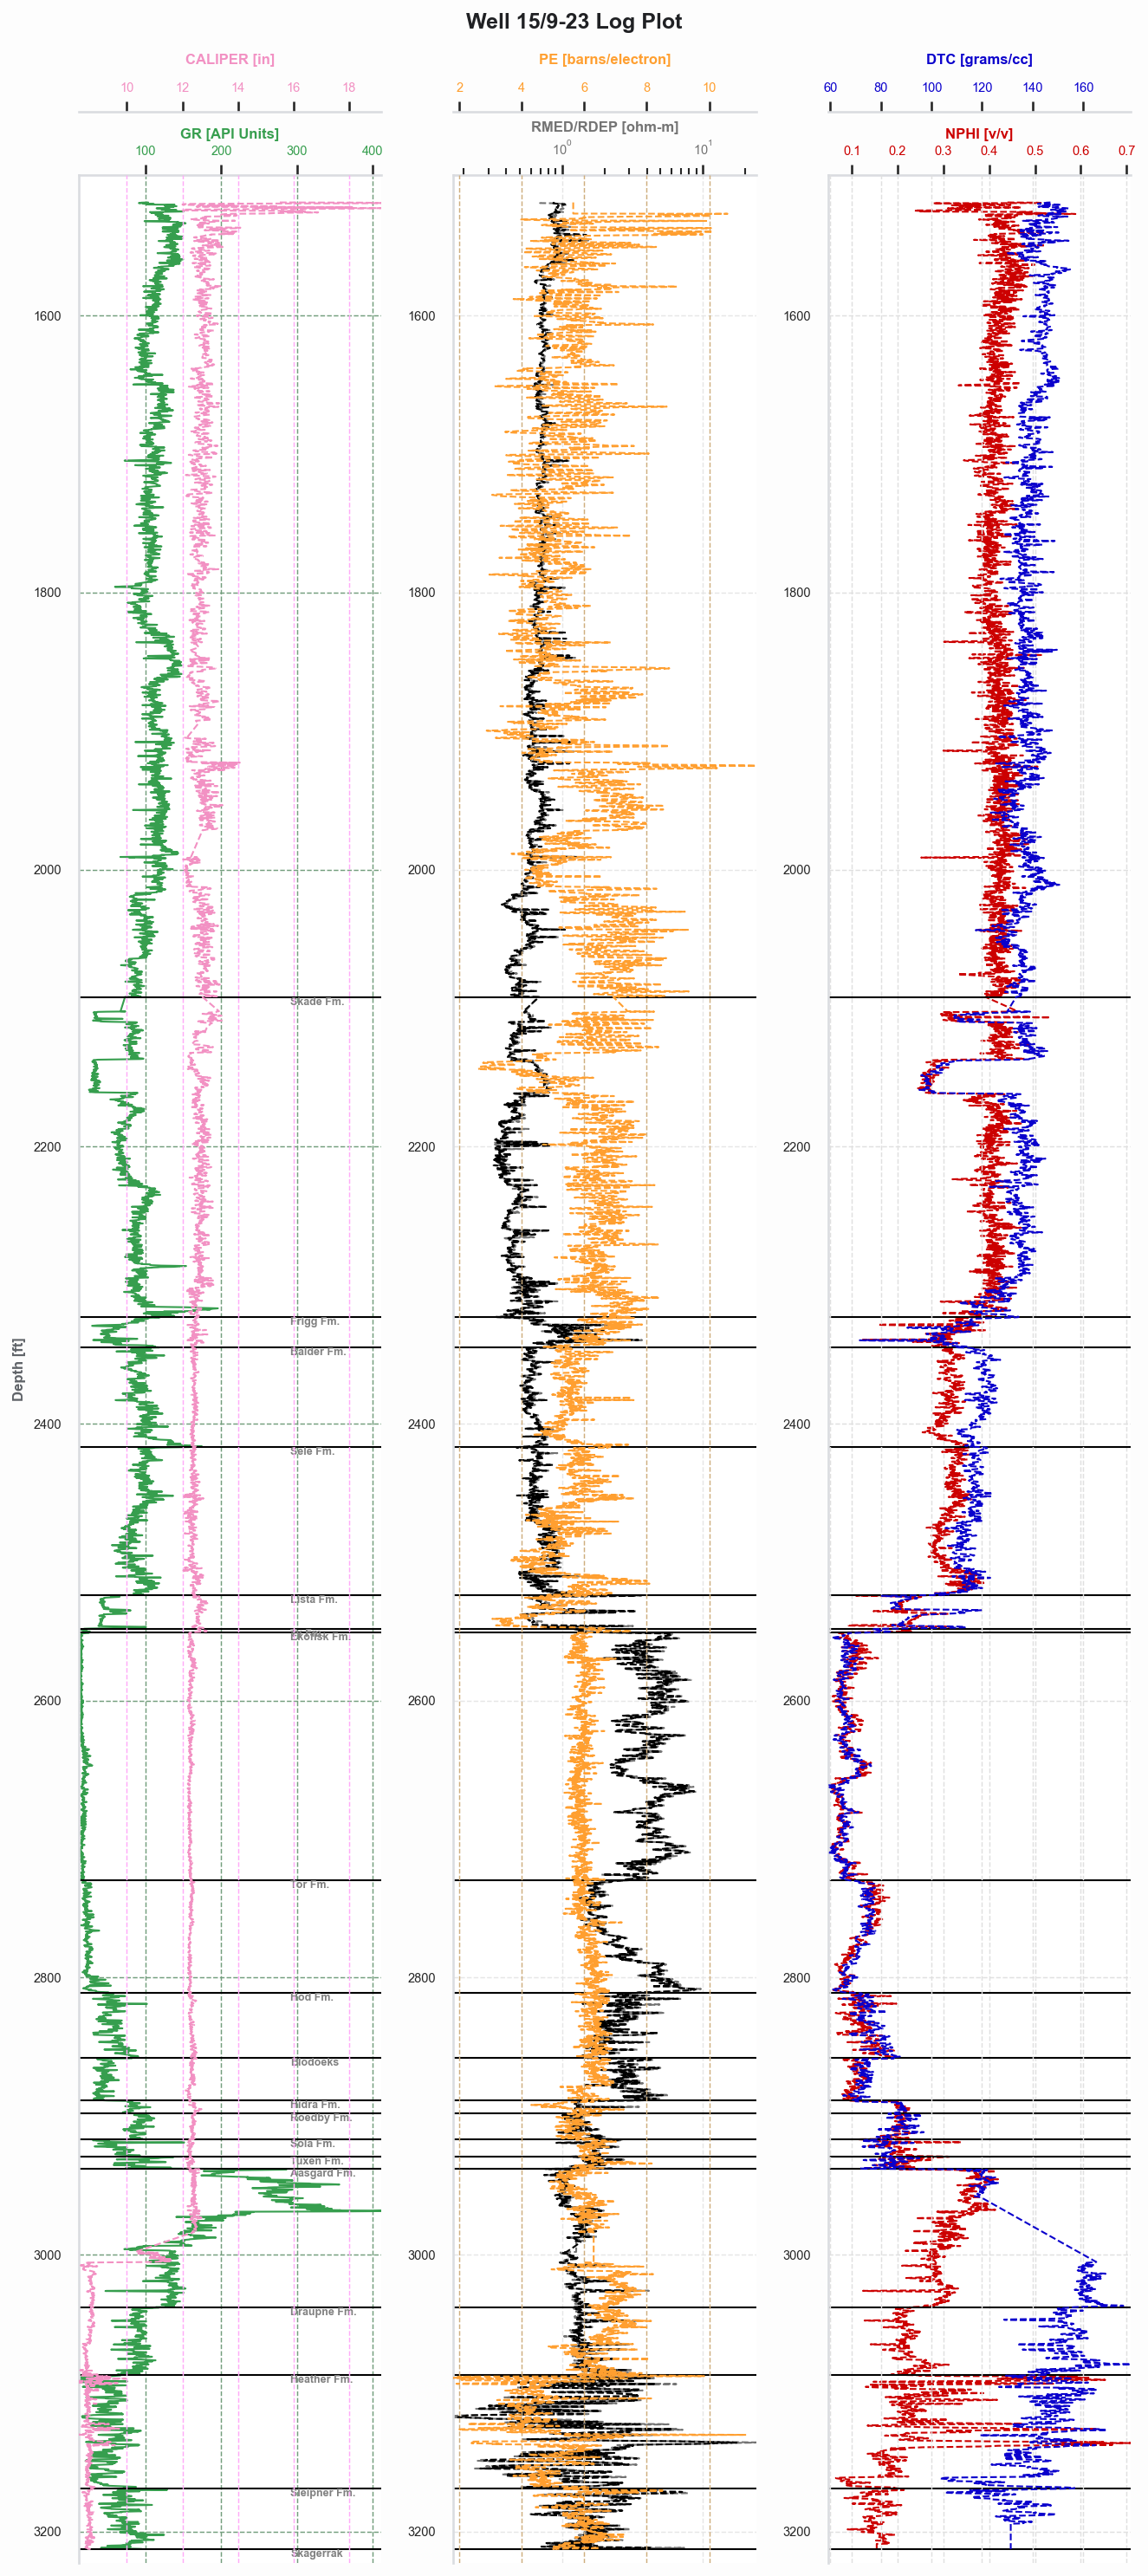

In [134]:
# Initialize Figure and Axes
fig, axes = plt.subplots(1, 3, figsize=(9, 20), dpi=150, facecolor='#fdfdfd')

# Setting the title
fig.suptitle(f"Well {well1['WELL'][0]} Log Plot", fontsize=12, fontweight='bold', color='#202124', y=0.99)

# Invert the axis to see the depth in order & giving Inner plot backgrounds
for ax in axes:
    ax.set_facecolor('#ffffff')
    ax.invert_yaxis()           

# Second axis for different scales in logs available for this well
ax0_twin = axes[0].twiny()
ax1_twin = axes[1].twiny()
ax2_twin = axes[2].twiny()

# explicitly force the twin axes to match the parent's limits:
ax0_twin.set_ylim(axes[0].get_ylim())
ax1_twin.set_ylim(axes[1].get_ylim())
ax2_twin.set_ylim(axes[2].get_ylim())

# Defining colors
gr_color = '#369e4e'
cal_color = '#f291c3'
rmed_color = '#737373'
rdep_color = '#000000'
pef_color = '#ff9f30'
nphi_color = '#cc0000'
dtc_color = '#0a00cc'

# Plot line fro Gamma-Ray log
line, = axes[0].plot(
    well1['GR'], well1['DEPTH_MD'], 
    color=gr_color,           
    linestyle='-',           
    linewidth=1,             
    label='GR [API Units]'  
)
# Plot line for Caliper log
line, = ax0_twin.plot(
    well1['CALI'], well1['DEPTH_MD'], 
    color=cal_color,           
    linestyle='--',           
    linewidth=1,             
    label='Caliper [in]'  
)
# *******************************************************
# Plot line for Medium Resistivity
line, = axes[1].plot(
    well1['RMED'], well1['DEPTH_MD'], 
    color=rmed_color,           
    linestyle='--',           
    linewidth=1,             
    label='RMED [ohm-m]'  
)
# Plot line for Deep Resistivity
line, = axes[1].plot(
    well1['RDEP'], well1['DEPTH_MD'], 
    color=rdep_color,           
    linestyle='--',           
    linewidth=1,             
    label='RMED [ohm-m]'  
)
# Plot line for PhotoElectric Factor
line, = ax1_twin.plot(
    well1['PEF'], well1['DEPTH_MD'], 
    color=pef_color,           
    linestyle='--',           
    linewidth=1,             
    label='PE [barns/electron]'  
)
# *******************************************************
# Plot line for NPHI
line, = axes[2].plot(
    well1['NPHI'], well1['DEPTH_MD'], 
    color=nphi_color,           
    linestyle='--',           
    linewidth=1,             
    label='NPHI [v/v]'  
)
# Plot line for DTC
line, = ax2_twin.plot(
    well1['DTC'], well1['DEPTH_MD'], 
    color=dtc_color,           
    linestyle='--',           
    linewidth=1,             
    label='Density [grams/cc]'  
)


# Limits ----------------------------------------------
# Y - Depth
y_min = well1['DEPTH_MD'].min() - 20
y_max = well1['DEPTH_MD'].max() + 10
# X 1st plot
ax0_min = well1['GR'].min()
ax0_max = well1['GR'].max()
ax0_twin_min = well1['CALI'].min()
ax0_twin_max = well1['CALI'].max()
# X 2nd plot
ax1_min = well1[['RMED', 'RDEP']].min().min()
ax1_max = well1[['RMED', 'RDEP']].max().max()
ax1_twin_min = well1['PEF'].min()
ax1_twin_max = well1['PEF'].max()
# X 3rd plot
ax2_min = well1['NPHI'].min()
ax2_max = well1['NPHI'].max()
ax2_twin_min = well1['DTC'].min()
ax2_twin_max = well1['DTC'].max()
# -----------------------------------------------------

# Fine-Tune Ticks and Limits
# 1st plot
axes[0].set_xlim(ax0_min, ax0_max)
axes[0].set_ylim(y_max, y_min)
axes[0].xaxis.tick_top()
axes[0].xaxis.set_label_position('top')
axes[0].tick_params(axis='both', which='major', labelsize=7)
axes[0].tick_params(axis='x', labelcolor=gr_color)
ax0_twin.xaxis.set_label_position('top')
ax0_twin.set_xlim(ax0_twin_min, ax0_twin_max)
ax0_twin.tick_params(axis='both', which='major', labelsize=7)
ax0_twin.tick_params(axis='x', labelcolor=cal_color)
# 2nd plot
axes[1].set_xlim(ax1_min, ax1_max)
axes[1].set_ylim(y_max, y_min)
axes[1].xaxis.tick_top()
axes[1].xaxis.set_label_position('top')
axes[1].tick_params(axis='both', which='major', labelsize=7)
axes[1].tick_params(axis='x', labelcolor=rmed_color)
axes[1].set_xscale('log')
ax1_twin.xaxis.set_label_position('top')
ax1_twin.set_xlim(ax1_twin_min, ax1_twin_max)
ax1_twin.tick_params(axis='both', which='major', labelsize=7)
ax1_twin.tick_params(axis='x', labelcolor=pef_color)
# 3rd plot
axes[2].set_xlim(ax2_min, ax2_max)
axes[2].set_ylim(y_max, y_min)
axes[2].xaxis.tick_top()
axes[2].xaxis.set_label_position('top')
axes[2].tick_params(axis='both', which='major', labelsize=7)
axes[2].tick_params(axis='x', labelcolor=nphi_color)
ax2_twin.xaxis.set_label_position('top')
ax2_twin.set_xlim(ax2_twin_min, ax2_twin_max)
ax2_twin.tick_params(axis='both', which='major', labelsize=7)
ax2_twin.tick_params(axis='x', labelcolor=dtc_color)

# Customize Axis Labels (Typography)
axes[0].set_xlabel('GR [API Units]', fontsize=8, fontweight='bold', color=gr_color)
axes[0].set_ylabel('Depth [ft]', fontsize=8, fontweight='bold', color='#5f6368')
ax0_twin.set_xlabel('CALIPER [in]', labelpad=10, fontweight='bold', fontsize=8, color=cal_color)

axes[1].set_xlabel('RMED/RDEP [ohm-m]', fontsize=8, fontweight='bold', color=rmed_color)
ax1_twin.set_xlabel('PE [barns/electron]', labelpad=10, fontweight='bold', fontsize=8, color=pef_color)

axes[2].set_xlabel('NPHI [v/v]', fontsize=8, fontweight='bold', color=nphi_color)
ax2_twin.set_xlabel('DTC [grams/cc]', labelpad=10, fontweight='bold', fontsize=8, color=dtc_color)

# Placing the grid behind the plot lines using zorder
axes[0].grid(True, which='major', linestyle='--', linewidth=0.7, color='#739e7d', zorder=0)
ax0_twin.grid(True, which='major', linestyle='--', linewidth=0.7, color='#ffabf8', zorder=0)
axes[1].grid(True, which='major', linestyle='--', linewidth=0.7, color='#e6e6e6', zorder=0)
ax1_twin.grid(True, which='major', linestyle='--', linewidth=0.7, color='#cfae7e', zorder=0)
axes[2].grid(True, which='major', linestyle='--', linewidth=0.7, color='#e0e0e0', zorder=0)
ax2_twin.grid(True, which='major', linestyle='--', linewidth=0.7, color='#e0e0e0', zorder=0)
line.set_zorder(3)  # Keep the line on top of the grid

# Clean Up Spines (Borders)
# Removing the top and right borders for a modern, open look
axes[0].spines['top'].set_visible(True)
axes[0].spines['top'].set_color('#dadce0')
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('#dadce0')
ax0_twin.spines['top'].set_position(('outward', 35))
ax0_twin.spines['top'].set_color('#dadce0')
ax0_twin.spines['bottom'].set_visible(False)
ax0_twin.spines['left'].set_visible(False)
ax0_twin.spines['right'].set_visible(False)

axes[1].spines['top'].set_visible(True)
axes[1].spines['top'].set_color('#dadce0')
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#dadce0')
ax1_twin.spines['top'].set_position(('outward', 35))
ax1_twin.spines['top'].set_color('#dadce0')
ax1_twin.spines['bottom'].set_visible(False)
ax1_twin.spines['left'].set_visible(False)
ax1_twin.spines['right'].set_visible(False)

axes[2].spines['top'].set_visible(True)
axes[2].spines['top'].set_color('#dadce0')
axes[2].spines['bottom'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].spines['left'].set_color('#dadce0')
ax2_twin.spines['top'].set_position(('outward', 35))
ax2_twin.spines['top'].set_color('#dadce0')
ax2_twin.spines['bottom'].set_visible(False)
ax2_twin.spines['left'].set_visible(False)
ax2_twin.spines['right'].set_visible(False)


# Printing the formations
for key, value in formations.items():

    axes[0].axhline(y=value, color='black', linestyle='-', linewidth=1)
    axes[0].text(x=0.7, y=value, s=key, color='gray', verticalalignment='top', fontweight='bold', fontsize=6, 
        transform=axes[0].get_yaxis_transform(), bbox=dict(facecolor='none', edgecolor='none', alpha=0.6))
    axes[1].axhline(y=value, color='black', linestyle='-', linewidth=1)
    axes[2].axhline(y=value, color='black', linestyle='-', linewidth=1)

# Tight Layout and Save
plt.tight_layout()
plt.show()


## **Building a Multi-Classification model**

#### **Decision Tree**

In [135]:
# Importing libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import tree

**Observation:** For this first approach, I decided to use only numerical variables. Then Scale the variables to use them later.

In [136]:
# Defining X and y
X = well1.drop(columns=['WELL', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'GROUP', 'FORMATION'])
y = well1['FORCE_2020_LITHOFACIES_LITHOLOGY']

# ------ Splitting ------
# First split: test and train/validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: The remaining % into Train and Validation.
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# ------ Scaling ------
# Initialize the scaler
minmax_scaler = MinMaxScaler()

# FIT ONLY ON TRAINING DATA to find the min and max values
X_train_minmax = minmax_scaler.fit_transform(X_train)

# ONLY TRANSFORM the validation and test sets using the boundaries learned from X_train
X_valid_minmax = minmax_scaler.transform(X_valid)
X_test_minmax = minmax_scaler.transform(X_test)

In [186]:
# Train and execute the model
model_dt = tree.DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
print(f'Training score: {round(model_dt.score(X_train, y_train)*100,2)}%.')
print(f'Validation score: {round(model_dt.score(X_valid, y_valid)*100,2)}%.')

Training score: 100.0%.
Validation score: 94.85%.


In [187]:
y_pred_dt = model_dt.predict(X_valid)
print(classification_report(y_valid, y_pred_dt))

              precision    recall  f1-score   support

       30000       0.90      0.90      0.90       120
       65000       0.98      0.99      0.98      1328
       65030       0.88      0.84      0.86       209
       70000       0.92      0.93      0.92       332
       70032       1.00      0.86      0.92         7
       80000       0.90      0.87      0.89       193
       90000       0.58      0.78      0.67         9
       99000       0.81      0.93      0.87        14

    accuracy                           0.95      2212
   macro avg       0.87      0.89      0.88      2212
weighted avg       0.95      0.95      0.95      2212



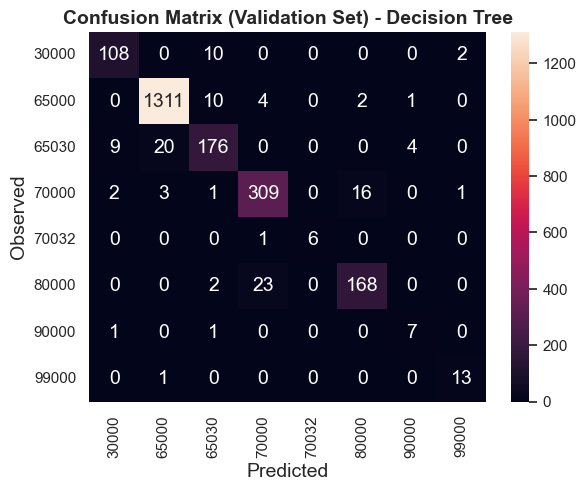

In [188]:
# Getting the classes from the model
target_names = model.classes_

# Printing the confusion matrix
cm = confusion_matrix(y_valid, y_pred_dt)
sns.heatmap(cm,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set) - Decision Tree', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [189]:
# Printing aditional information from the model obtained
print(f'Model Depth: {model_dt.get_depth()}.')
print(f'Model # of leaves: {model_dt.get_n_leaves()}.')

Model Depth: 18.
Model # of leaves: 234.


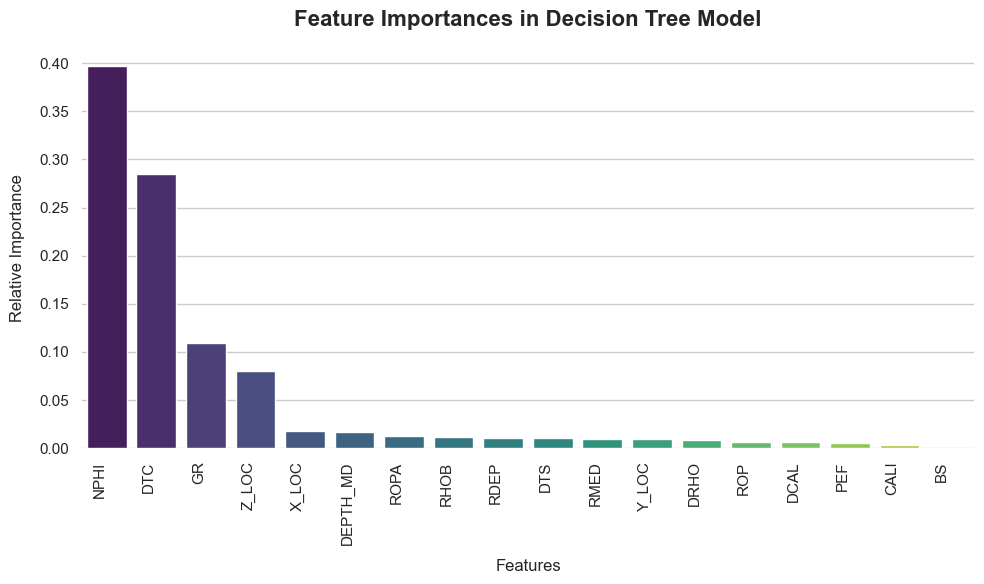

In [190]:
# Showing the feature importance in the Decision Tree
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_dt.feature_importances_
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Feature', 
    y='Importance', 
    data=importance_df, 
    palette='viridis'
)
plt.title('Feature Importances in Decision Tree Model', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=12, labelpad=10)
plt.ylabel('Relative Importance', fontsize=12, labelpad=10)
plt.xticks(rotation=90, ha="right")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Observation:** The most important features are the logs NPHI, DTC and GR.

In [192]:
X.columns

Index(['DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'CALI', 'RMED', 'RDEP', 'RHOB',
       'GR', 'NPHI', 'PEF', 'DTC', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'ROPA'],
      dtype='object')

In [191]:
model_dt.predict([[
    2308.528, 433918.3, 6459994.0, -2283.35, 12.27941, 0.644152, 
    0.628472, 2.383946, 88.25098, 0.368354, 7.856128, 122.7796, 
    12.25, 134.4406, 283.0198, 0.029412, 0.046487, 121.2562
]])

array([65000])

In [193]:
# Testing values manually to evaluate model performance
max_depth = []
acc_gini = []
acc_entropy = []

for i in range(1, 21):
    model = tree.DecisionTreeClassifier(criterion='gini', max_depth=i)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    acc_gini.append(model.score(X_valid,y_valid))

    model = tree.DecisionTreeClassifier(criterion='entropy', max_depth=i)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    acc_entropy.append(model.score(X_valid,y_valid))

    max_depth.append(i)

# Storing the results into a dataframe  
d = pd.DataFrame({'max_depth': max_depth,
                  'acc_gini': acc_gini,
                  'acc_entropy': acc_entropy})

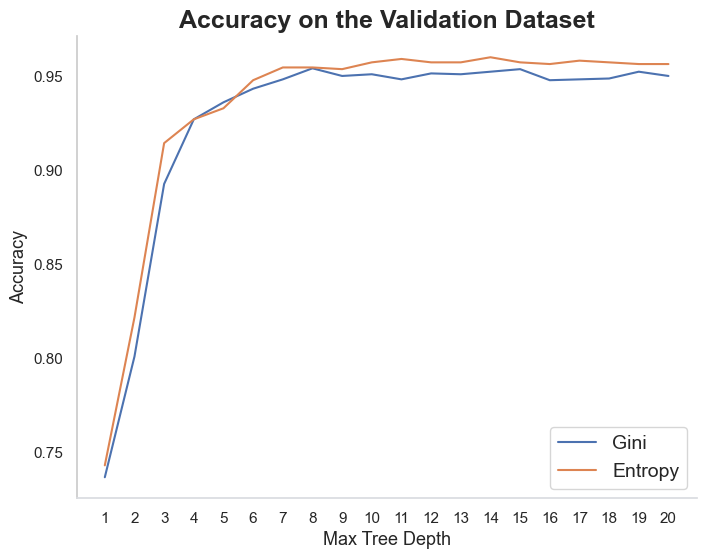

In [194]:
# Plotting the results
plt.figure(figsize = (8, 6))
plt.plot(d.max_depth, d.acc_gini, label='Gini')
plt.plot(d.max_depth, d.acc_entropy, label='Entropy')
plt.xlabel('Max Tree Depth', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy on the Validation Dataset', fontsize=18, weight='bold')
plt.grid()
plt.xticks(max_depth)
plt.legend(fontsize=14)

# Removing the top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#dadce0')
plt.show()

**GridSearch**

In [146]:
# Testing GridSearch
from sklearn.model_selection import GridSearchCV

gs_model = GridSearchCV(estimator = tree.DecisionTreeClassifier(), 
                 param_grid={'max_depth': range(5, 25),   
                             'min_samples_split': range(2, 11),      
                             'criterion': ['entropy']},   
                 cv=5,
                 scoring="accuracy")

# Fitting the data
gs_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy'], 'max_depth': range(5, 25), 'min_samples_split': range(2, 11)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [147]:
print(gs_model.best_params_)

{'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 5}


In [148]:
print(gs_model.best_score_)

0.955840241145441


In [149]:
gs_model.score(X_valid, y_valid)

0.9566003616636528

In [207]:
best_dt_gs = gs_model.best_estimator_

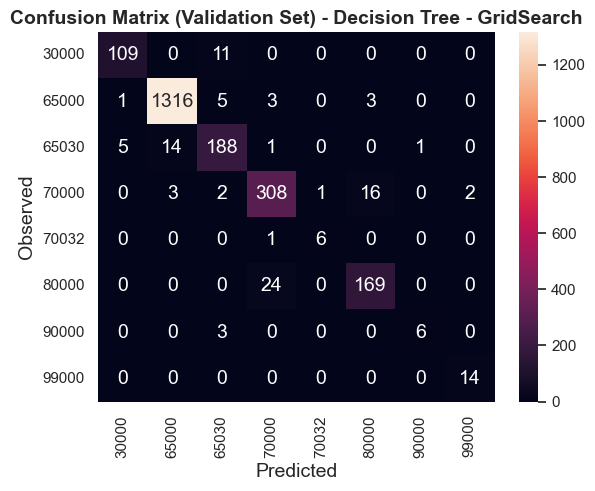

In [150]:
# Printing the confusion matrix
y_pred_gs = gs_model.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred_gs)
sns.heatmap(cm,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set) - Decision Tree - GridSearch', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

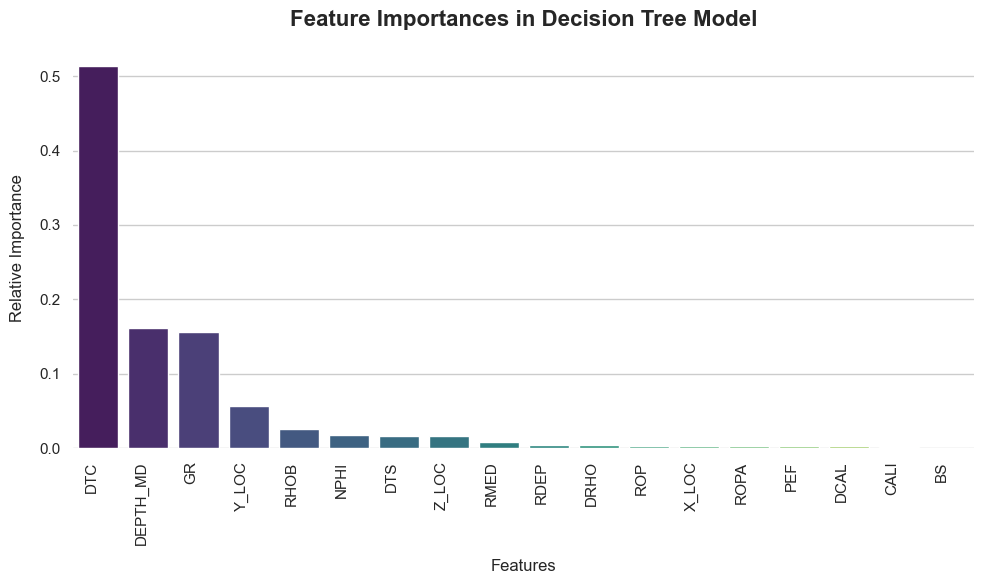

In [151]:
# Showing the feature importance in the Decision Tree
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gs_model.best_estimator_.feature_importances_
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Feature', 
    y='Importance', 
    data=importance_df, 
    palette='viridis'
)
plt.title('Feature Importances in Decision Tree Model', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=12, labelpad=10)
plt.ylabel('Relative Importance', fontsize=12, labelpad=10)
plt.xticks(rotation=90, ha="right")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### **Logistic Regression**

In [30]:
from sklearn.linear_model import LogisticRegression

In [152]:
model_lr = LogisticRegression(max_iter=10_000)
model_lr.fit(X_train_minmax, y_train)
print(f'Training score: {round(model_lr.score(X_train_minmax, y_train)*100,2)}%.')
print(f'Validation score: {round(model_lr.score(X_valid_minmax, y_valid)*100,2)}%.')

Training score: 91.61%.
Validation score: 92.22%.


In [153]:
y_pred_lr = model_lr.predict(X_valid_minmax)
print(classification_report(y_valid, y_pred_lr))

              precision    recall  f1-score   support

       30000       0.95      0.75      0.84       120
       65000       0.96      0.98      0.97      1328
       65030       0.79      0.77      0.78       209
       70000       0.90      0.92      0.91       332
       70032       0.00      0.00      0.00         7
       80000       0.85      0.89      0.87       193
       90000       0.89      0.89      0.89         9
       99000       1.00      0.07      0.13        14

    accuracy                           0.92      2212
   macro avg       0.79      0.66      0.67      2212
weighted avg       0.92      0.92      0.92      2212



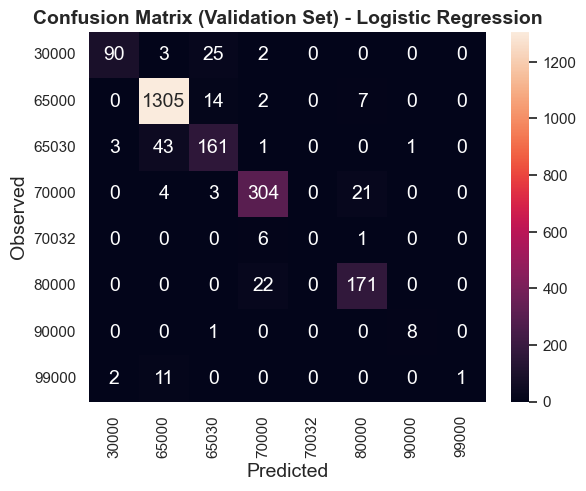

In [154]:
# Printing the confusion matrix
cm_lr = confusion_matrix(y_valid, y_pred_lr)
sns.heatmap(cm_lr,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set) - Logistic Regression', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### GridSearch

In [155]:
# Defining the model
model_lr_2 = LogisticRegression(random_state=42, max_iter=1000)

# Defining the parameters to test
param_grid = [
    {
        # lbfgs and newton-cg only support l2 or no penalty
        'solver': ['lbfgs', 'newton-cg'],
        'penalty': ['l2', None],
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    {
        # saga supports l1, l2, and no penalty well (good for large datasets)
        'solver': ['saga'],
        'penalty': ['l1', 'l2', None],
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    }
]

grid_search = GridSearchCV(
    estimator=model_lr_2,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Run the Grid Search
grid_search.fit(X_train_minmax, y_train)

# Output the results
print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Extract the winning model for future use
best_log_reg_model = grid_search.best_estimator_


--- Grid Search Results ---
Best Parameters: {'C': 0.001, 'penalty': None, 'solver': 'newton-cg'}
Best Cross-Validation Accuracy: 0.9412


In [ ]:
y_pred_lr_gs = best_log_reg_model.predict(X_valid_minmax)
print(classification_report(y_valid, y_pred_lr_gs))

              precision    recall  f1-score   support

       30000       0.88      0.88      0.88       120
       65000       0.98      0.99      0.99      1328
       65030       0.85      0.82      0.83       209
       70000       0.90      0.92      0.91       332
       70032       1.00      0.71      0.83         7
       80000       0.88      0.87      0.88       193
       90000       0.58      0.78      0.67         9
       99000       0.81      0.93      0.87        14

    accuracy                           0.94      2212
   macro avg       0.86      0.86      0.86      2212
weighted avg       0.94      0.94      0.94      2212



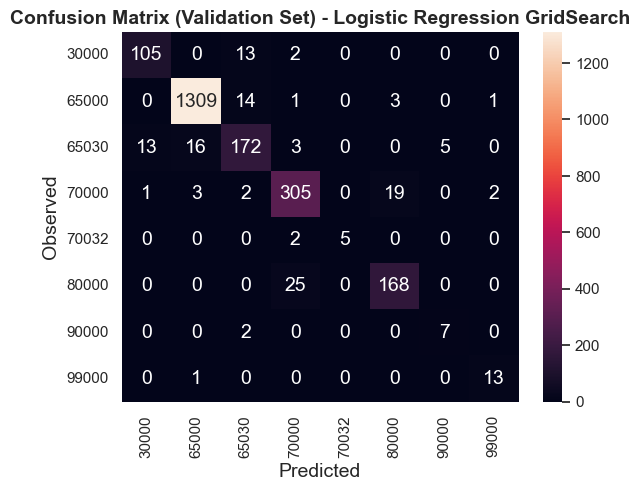

In [157]:
# Printing the confusion matrix
cm_lr_gs = confusion_matrix(y_valid, y_pred_lr_gs)
sns.heatmap(cm_lr_gs,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set) - Logistic Regression GridSearch', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### **ANN**

In [158]:
from tensorflow.keras import models, layers, optimizers

In [37]:
# Encoding target variables in all folds:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_valid_enc = label_encoder.fit_transform(y_valid)
y_test_enc = label_encoder.fit_transform(y_test)

In [159]:
# Use one hidden layer

ann1 = models.Sequential([
    layers.Input(shape=(18,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(8, activation='softmax')
])

ann1.compile(optimizer='adam', 
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

ann1.fit(X_train_minmax, y_train_enc, epochs=10)

Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7567 - loss: 0.7787
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8473 - loss: 0.4550
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8717 - loss: 0.3743
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8898 - loss: 0.3280
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8996 - loss: 0.2977
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9093 - loss: 0.2749
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9156 - loss: 0.2623
Epoch 8/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9188 - loss: 0.2493
Epoch 9/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9212 - loss: 0.2416
Epoch 10/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9224 - loss: 0.2342


In [160]:
ann1.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,762 (81.11 KB)

 Trainable params: 6,920 (27.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,842 (54.07 KB)

In [161]:
ann1.evaluate(X_valid_minmax, y_valid_enc)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9295 - loss: 0.2421


[0.2420787513256073, 0.9294756054878235]

In [163]:
import keras

# Use two hidden layers

ann1 = models.Sequential([
    layers.Input(shape=(18,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(8, activation='softmax')
])

opt1 = keras.optimizers.RMSprop(learning_rate=0.001)
opt2 = keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.001)
opt3 = keras.optimizers.Adam(learning_rate=0.001)

ann1.compile(optimizer = opt3, 
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])


# Pass this dictionary into the fit function
ann1.fit(X_train_minmax, y_train_enc, epochs=20)

Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7632 - loss: 0.6869
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8699 - loss: 0.3697
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9010 - loss: 0.2991
Epoch 4/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9150 - loss: 0.2610
Epoch 5/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9221 - loss: 0.2353
Epoch 6/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9239 - loss: 0.2214
Epoch 7/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9271 - loss: 0.2120
Epoch 8/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9299 - loss: 0.1985
Epoch 9/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9328 - loss: 0.1948
Epoch 10/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9320 - loss: 0.1883
Epoch 11/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9372 - loss: 0.1827
Epoch 12/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [165]:
ann1.evaluate(X_valid_minmax, y_valid_enc)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9435 - loss: 0.1785


[0.1784639060497284, 0.9434900283813477]

In [166]:
# Evaluating a single data record
X_new = pd.DataFrame([[
    2308.528, 433918.3, 6459994.0, -2283.35, 12.27941, 0.644152, 
    0.628472, 2.383946, 88.25098, 0.368354, 7.856128, 122.7796, 
    12.25, 134.4406, 283.0198, 0.029412, 0.046487, 121.2562
]])
X_new_scaled = minmax_scaler.transform(X_new)
probabilities = ann1.predict(X_new_scaled)
print("Raw Probabilities:\n", probabilities)
predicted_indices = np.argmax(probabilities, axis=1)
print("Predicted Class Indices:", predicted_indices)
final_predictions = label_encoder.inverse_transform(predicted_indices)
print("Actual Predicted Values:", final_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Raw Probabilities:
 [[3.4657317e-06 9.9734300e-01 1.7172478e-03 8.6374261e-04 1.4658631e-12
  1.9297616e-08 2.4962358e-07 7.2332041e-05]]
Predicted Class Indices: [1]
Actual Predicted Values: [65000]


In [167]:
y_pred_ann = ann1.predict(X_valid_minmax)
y_pred_indices = np.argmax(y_pred_ann, axis=1)
y_pred_final = label_encoder.inverse_transform(y_pred_indices)
print(classification_report(y_valid, y_pred_final))

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

       30000       0.90      0.86      0.88       120
       65000       0.99      0.98      0.98      1328
       65030       0.80      0.92      0.86       209
       70000       0.90      0.95      0.92       332
       70032       1.00      0.71      0.83         7
       80000       0.91      0.83      0.87       193
       90000       1.00      0.89      0.94         9
       99000       0.75      0.64      0.69        14

    accuracy                           0.94      2212
   macro avg       0.91      0.85      0.87      2212
weighted avg       0.95      0.94      0.94      2212



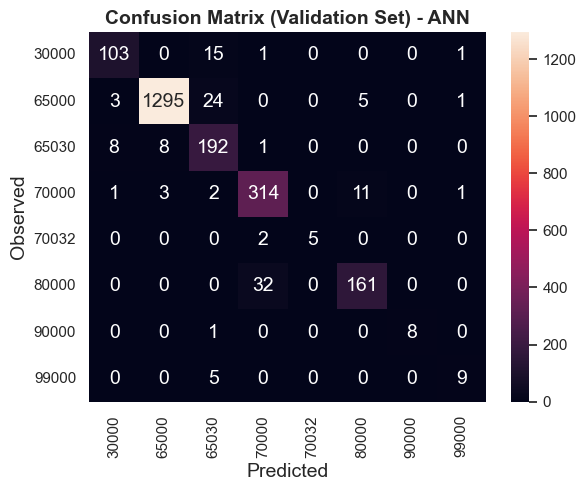

In [169]:
# Printing the confusion matrix
cm_ann = confusion_matrix(y_valid, y_pred_final)
sns.heatmap(cm_ann,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set) - ANN', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### **KNN**

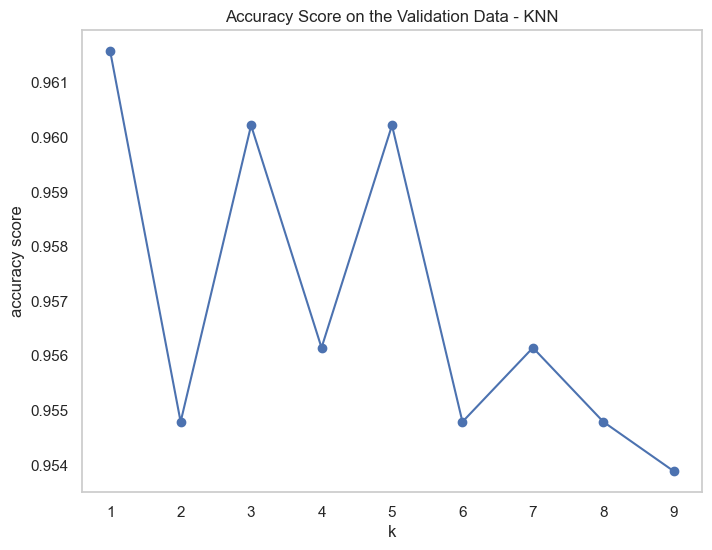

In [171]:
from sklearn.neighbors import KNeighborsClassifier

k_values = []
acc_score = []
acc_score_valid = []

for k in range(1, 10, 1):
    model_knn = KNeighborsClassifier(n_neighbors = k)
    model_knn.fit(X_train_minmax, y_train)
    y_pred_knn = model_knn.predict(X_valid_minmax)
    acc_score.append(accuracy_score(y_valid, y_pred_knn))
    k_values.append(k)


plt.figure(figsize = (8, 6))

plt.plot(k_values, acc_score, marker = "o")
plt.title("Accuracy Score on the Validation Data - KNN")
plt.xlabel("k")
plt.ylabel("accuracy score")
plt.xticks(k_values)
plt.grid();

**Observation**: The best result is with a value of k=5.

In [172]:
model_knn = KNeighborsClassifier(n_neighbors = 5)
model_knn.fit(X_train_minmax, y_train)
y_pred_knn = model_knn.predict(X_valid_minmax)
print(classification_report(y_valid, y_pred_knn))

              precision    recall  f1-score   support

       30000       0.89      0.91      0.90       120
       65000       0.99      0.99      0.99      1328
       65030       0.92      0.91      0.92       209
       70000       0.93      0.94      0.94       332
       70032       1.00      0.71      0.83         7
       80000       0.91      0.89      0.90       193
       90000       0.89      0.89      0.89         9
       99000       0.87      0.93      0.90        14

    accuracy                           0.96      2212
   macro avg       0.92      0.90      0.91      2212
weighted avg       0.96      0.96      0.96      2212



In [175]:
print(f'Training score: {round(model_knn.score(X_train_minmax, y_train)*100,2)}%.')
print(f'Validation score: {round(model_knn.score(X_valid_minmax, y_valid)*100,2)}%.')

Training score: 97.36%.
Validation score: 96.02%.


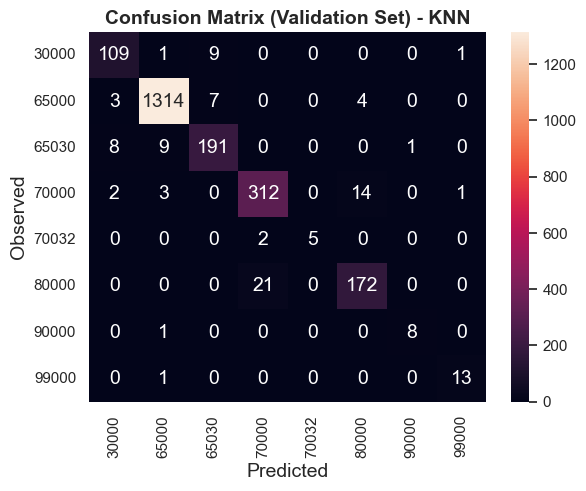

In [174]:
# Printing the confusion matrix
cm_knn = confusion_matrix(y_valid, y_pred_knn)
sns.heatmap(cm_knn,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set) - KNN', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### **NB**

In [176]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
model_nb = GaussianNB()
model_nb.fit(X_train_minmax, y_train)

print(f'Training score: {round(model_nb.score(X_train_minmax, y_train)*100,2)}%.')
print(f'Validation score: {round(model_nb.score(X_valid_minmax, y_valid)*100,2)}%.')


Training score: 84.17%.
Validation score: 84.04%.


In [177]:
y_pred_nb = model_nb.predict(X_valid_minmax)
print(classification_report(y_valid, y_pred_nb))

              precision    recall  f1-score   support

       30000       0.82      0.48      0.61       120
       65000       0.96      0.92      0.94      1328
       65030       0.54      0.54      0.54       209
       70000       0.95      0.77      0.85       332
       70032       0.50      1.00      0.67         7
       80000       0.72      0.94      0.81       193
       90000       0.10      1.00      0.18         9
       99000       0.37      1.00      0.54        14

    accuracy                           0.84      2212
   macro avg       0.62      0.83      0.64      2212
weighted avg       0.88      0.84      0.85      2212



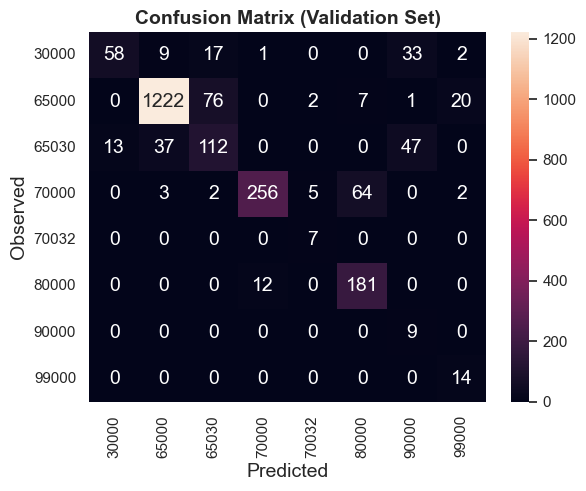

In [178]:
# Printing the confusion matrix
cm_nb = confusion_matrix(y_valid, y_pred_nb)
sns.heatmap(cm_nb,
           annot=True,
           annot_kws={"size":14},
           fmt=".0f",
           xticklabels=target_names,
           yticklabels=target_names)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.title('Confusion Matrix (Validation Set)', fontsize=14, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### GridSearch with Multinomial Model

In [182]:
# Initialize the model
model_mnb = MultinomialNB()

# Define the parameter grid
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

# Set up the Grid Search 
grid_search = GridSearchCV(estimator=model_mnb,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Fit the model to find the best parameters
grid_search.fit(X_train_minmax, y_train)

# 6. View the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'alpha': 10.0, 'fit_prior': False}
Best Cross-Validation Accuracy: 0.8185


In [183]:
# Extract the winning model for future use
best_nb_model = grid_search.best_estimator_
y_pred_nb_gs = best_nb_model.predict(X_valid_minmax)
print(classification_report(y_valid, y_pred_nb_gs))

              precision    recall  f1-score   support

       30000       0.12      0.09      0.11       120
       65000       0.96      0.87      0.91      1328
       65030       0.43      0.72      0.54       209
       70000       0.92      0.91      0.92       332
       70032       0.00      0.00      0.00         7
       80000       0.78      0.89      0.83       193
       90000       0.80      0.89      0.84         9
       99000       0.50      0.64      0.56        14

    accuracy                           0.82      2212
   macro avg       0.57      0.63      0.59      2212
weighted avg       0.84      0.82      0.82      2212



## **Conclusions**

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


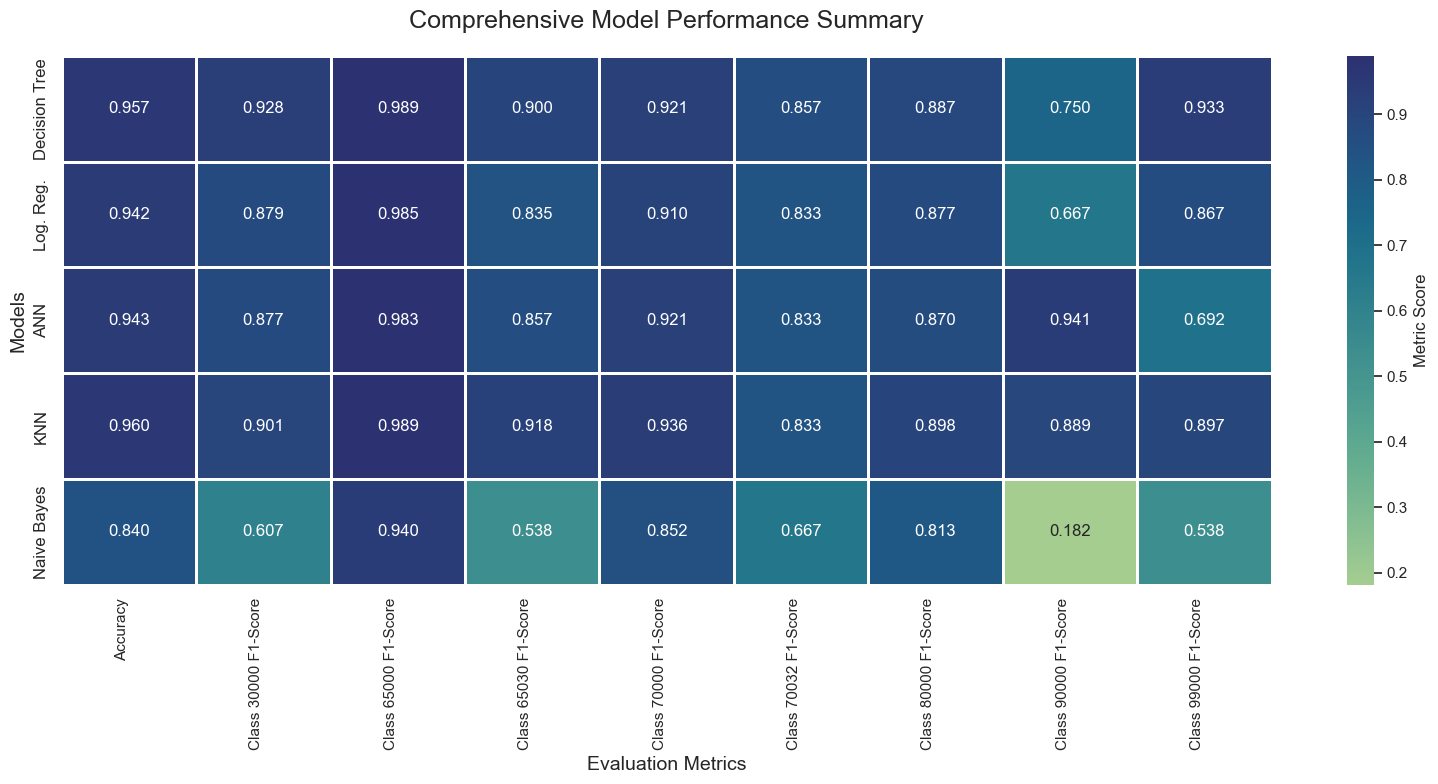

In [213]:
# Group the best models into a dictionary
best_models = {
    'Decision Tree': best_dt_gs,
    'Log. Reg.': best_log_reg_model,
    'ANN': ann1,
    'KNN': model_knn,
    'Naive Bayes': model_nb
}

# Extract metrics for all models
results_list = []

for name, model in best_models.items():
    
    # Predict on the validation set (depending the model)

    y_pred = model.predict(X_valid_minmax)
    
    if name == "Decision Tree":
        y_pred = model.predict(X_valid)
    
    if name == 'ANN':
        y_pred_ann = ann1.predict(X_valid_minmax)
        y_pred_indices = np.argmax(y_pred_ann, axis=1)
        y_pred = label_encoder.inverse_transform(y_pred_indices)
        
    # Generate the classification report as a dictionary
    report = classification_report(y_valid, y_pred, output_dict=True)
    
    # Start building a row for this model
    model_metrics = {'Accuracy': report['accuracy']}
    
    # Loop through the dictionary to extract class-specific metrics
    for key, value in report.items():
        # Ignore the summary averages for the class-specific breakdown
        if key not in ['accuracy', 'macro avg', 'weighted avg']:
            # 'key' here is the class name/number
            #model_metrics[f'Class {key} Precision'] = value['precision']
            #model_metrics[f'Class {key} Recall'] = value['recall']
            model_metrics[f'Class {key} F1-Score'] = value['f1-score']
            
    # Add the model name and append to our list
    model_metrics['Model'] = name
    results_list.append(model_metrics)

# Convert to a DataFrame and set the Model name as the index
df_results = pd.DataFrame(results_list).set_index('Model')

# Sorting columns so Accuracy is first, followed by classes
cols = ['Accuracy'] + [c for c in df_results.columns if c != 'Accuracy']
df_results = df_results[cols]

# Plot the Modern Heatmap
plt.figure(figsize=(16, 8))

# Create a custom color map
sns.heatmap(df_results, annot=True, cmap='crest', fmt='.3f', 
            linewidths=1, linecolor='white', cbar_kws={'label': 'Metric Score'})

# Formatting the graph
plt.title('Comprehensive Model Performance Summary', fontsize=18, pad=20)
plt.xlabel('Evaluation Metrics', fontsize=14)
plt.ylabel('Models', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=11)
plt.yticks(fontsize=12)

# Ensure layout isn't cut off
plt.tight_layout()
plt.show()